In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [63]:
df=pd.read_csv("/content/insurance.csv")

In [64]:
df


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [65]:
df.shape

(1338, 7)

In [66]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [67]:
df.duplicated().sum()

np.int64(1)

In [68]:
df.duplicated().sum()

np.int64(1)

In [69]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [70]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

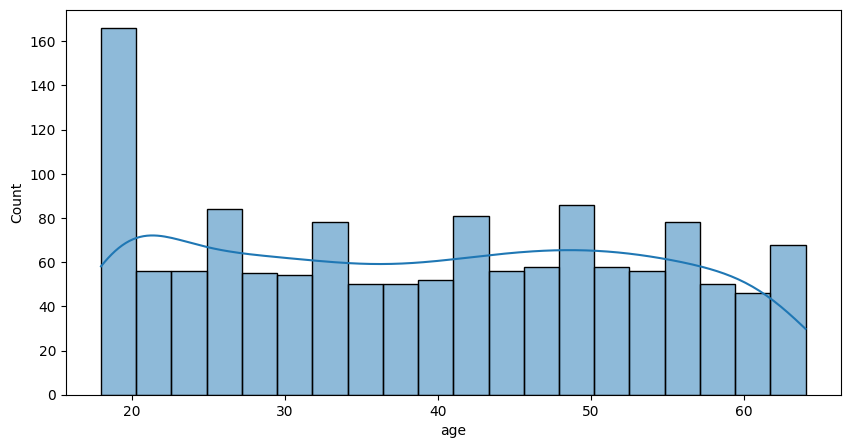

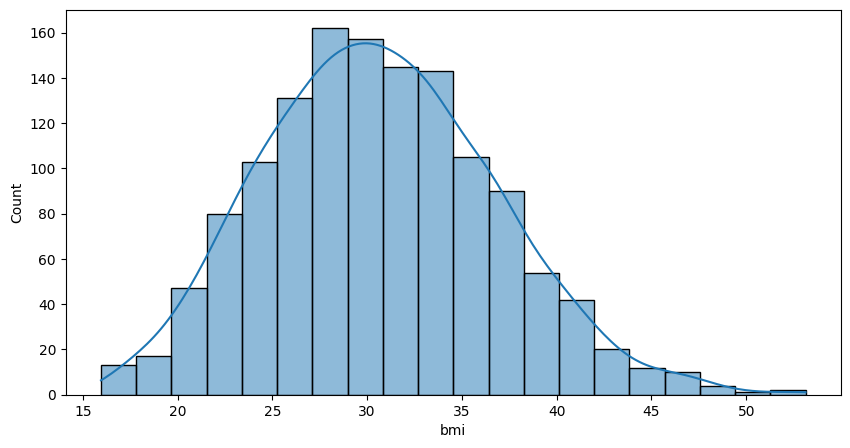

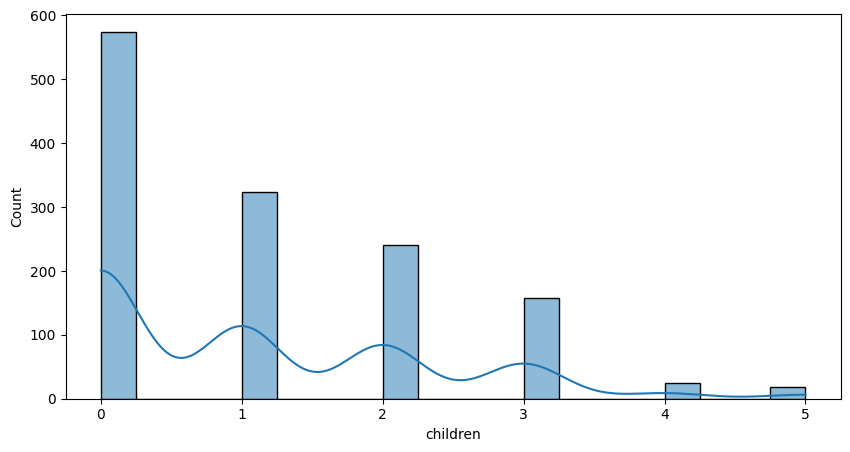

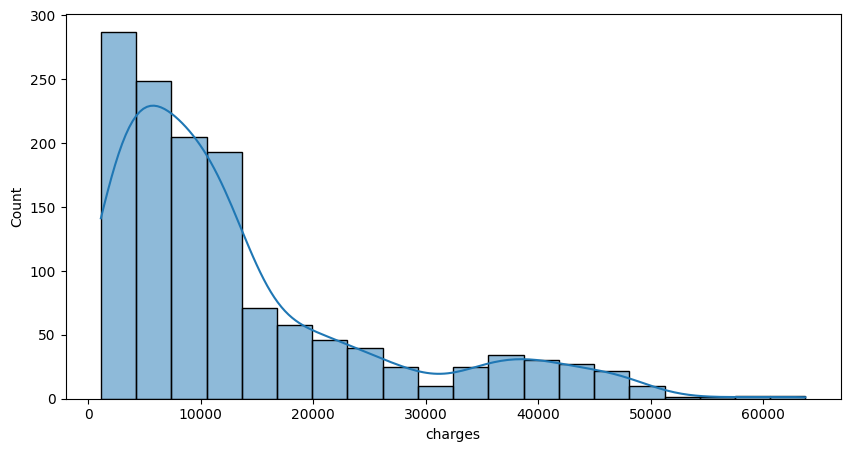

In [71]:
numeric_col=['age', 'bmi', 'children','charges']
for col in numeric_col:
  plt.figure(figsize=(10,5))
  sns.histplot(df[col],kde=True,bins=20)
  plt.xlabel(col)

  plt.show()

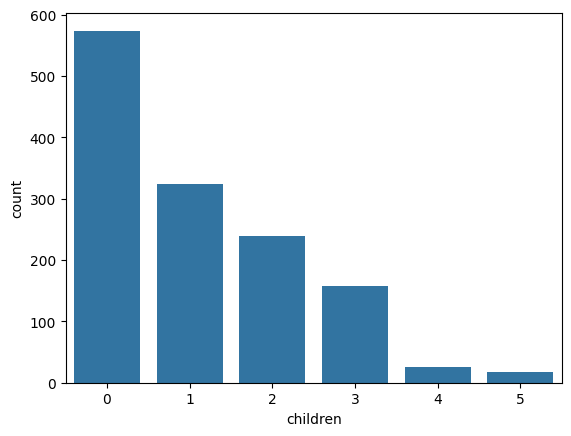

In [72]:
sns.countplot(x=df['children'])
plt.show()

<Axes: xlabel='children', ylabel='count'>

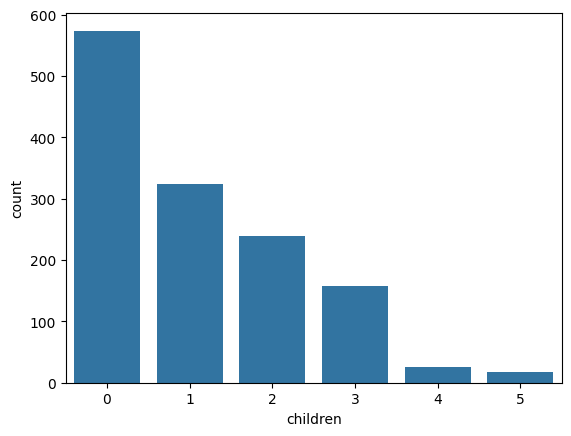

In [73]:
sns.countplot(x=df['children'])

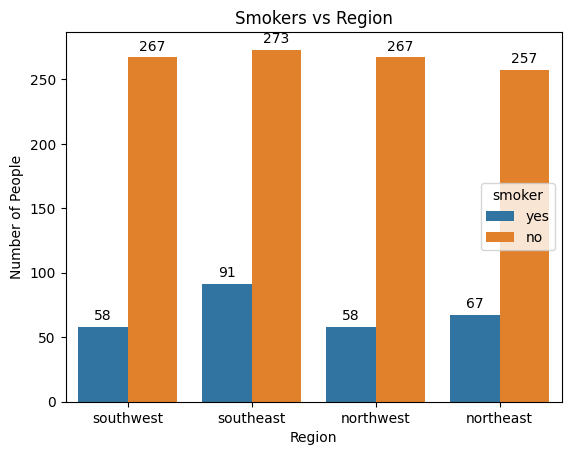

In [74]:
x=sns.countplot(data=df, x="region", hue="smoker")

plt.title("Smokers vs Region")
plt.xlabel("Region")
plt.ylabel("Number of People")
for container in x.containers:
  x.bar_label(container, fmt='%d', padding=3)

plt.show()

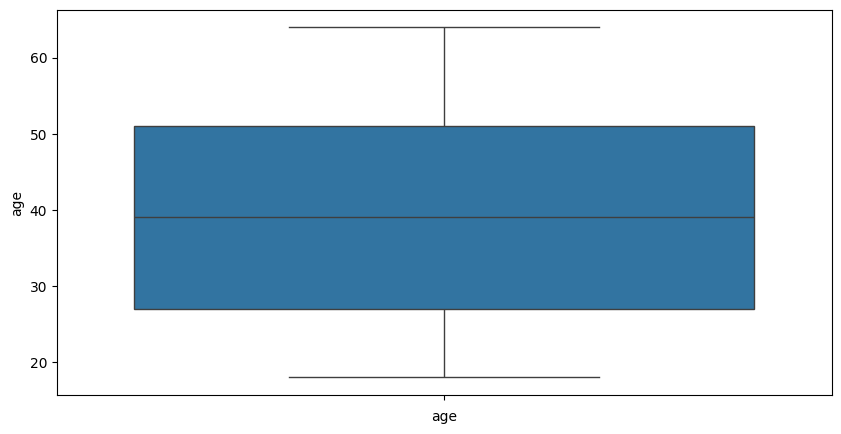

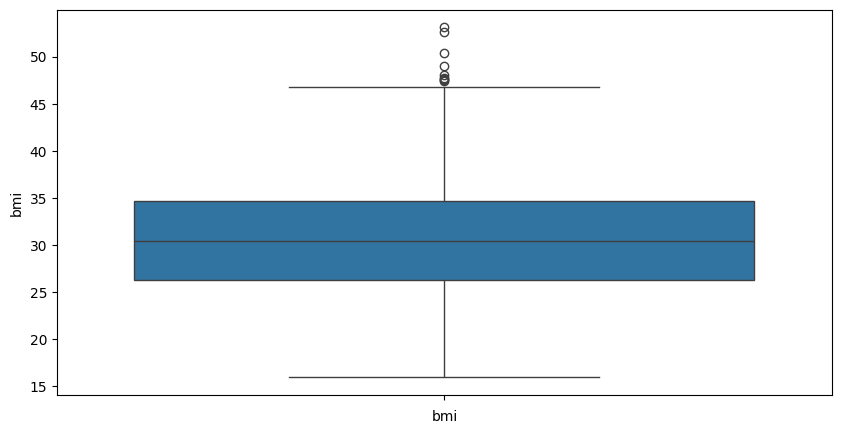

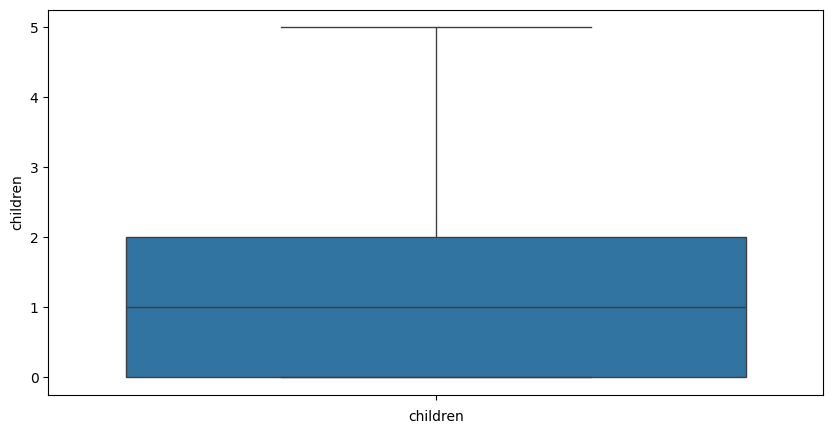

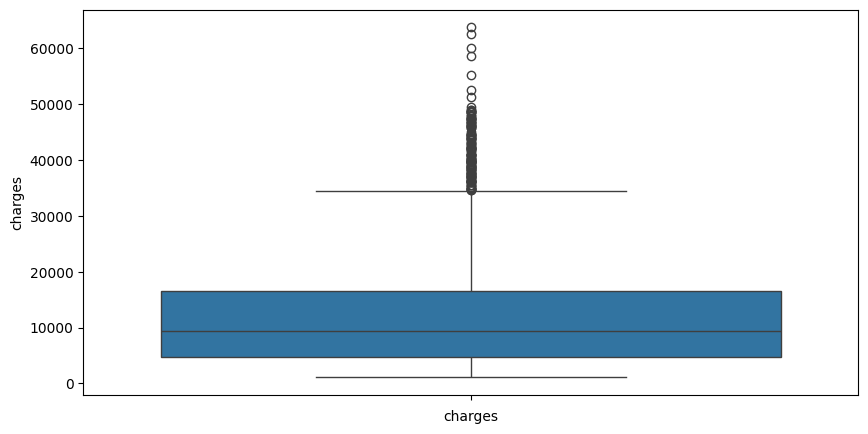

In [75]:
for col in numeric_col:
  plt.figure(figsize=(10,5))
  sns.boxplot(df[col])
  plt.xlabel(col)
  plt.show()

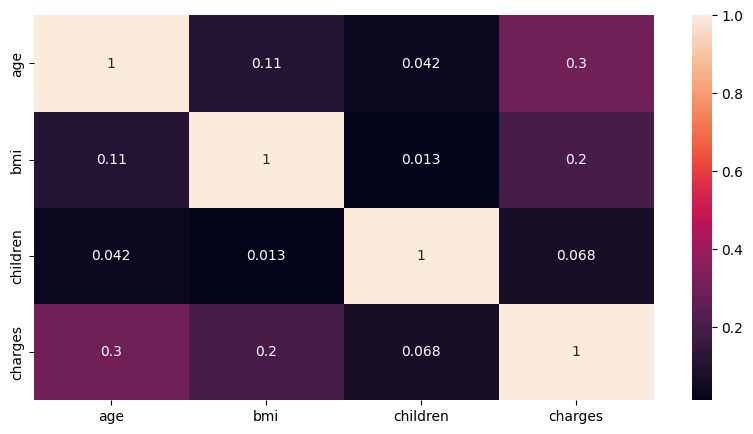

In [76]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

Data cleaning

In [77]:
df_cleaned=df.copy()

In [78]:
df_cleaned.drop_duplicates(inplace=True)

In [79]:
df.shape

(1338, 7)

In [80]:
df_cleaned['age'].value_counts()

,count
age,
18,69
19,67
46,29
52,29
50,29
47,29
48,29
51,29
45,29


In [81]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [83]:
df_cleaned['sex']=df_cleaned['sex'].map({'female':0,'male':1})
df_cleaned['smoker']=df_cleaned['smoker'].map({'yes':1,'no':0})
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


In [84]:
df_cleaned['smoker'].value_counts()

,count
smoker,
0,1063
1,274


In [85]:
df_cleaned.rename(columns={
    'sex': 'is_female',
    'smoker': 'is_smoker'
}, inplace=True)

In [86]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'region',
       'charges'],
      dtype='object')

In [87]:
df_cleaned

,age,is_female,bmi,children,is_smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


In [88]:
df_cleaned

,age,is_female,bmi,children,is_smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


<Axes: xlabel='bmi', ylabel='Count'>

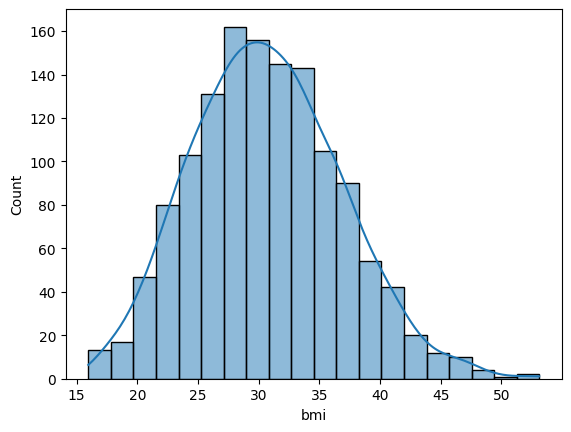

In [89]:
sns.histplot(df_cleaned['bmi'],kde=True,bins=20)

In [90]:
pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 25, 30, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

,bmi
0,Overweight
1,Obese
2,Obese
3,Normal
4,Overweight
...,...
1333,Obese
1334,Obese
1335,Obese
1336,Overweight


In [91]:
df_cleaned

,age,is_female,bmi,children,is_smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


In [92]:
df_cleaned['bmi_level'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 25, 30, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [93]:
df_cleaned

,age,is_female,bmi,children,is_smoker,region,charges,bmi_level
0,19,0,27.900,0,1,southwest,16884.92400,Overweight
1,18,1,33.770,1,0,southeast,1725.55230,Obese
2,28,1,33.000,3,0,southeast,4449.46200,Obese
3,33,1,22.705,0,0,northwest,21984.47061,Normal
4,32,1,28.880,0,0,northwest,3866.85520,Overweight
...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830,Obese
1334,18,0,31.920,0,0,northeast,2205.98080,Obese
1335,18,0,36.850,0,0,southeast,1629.83350,Obese
1336,21,0,25.800,0,0,southwest,2007.94500,Overweight


In [94]:
print(df_cleaned[['bmi', 'bmi_level']].head(10))

      bmi   bmi_level
0  27.900  Overweight
1  33.770       Obese
2  33.000       Obese
3  22.705      Normal
4  28.880  Overweight
5  25.740  Overweight
6  33.440       Obese
7  27.740  Overweight
8  29.830  Overweight
9  25.840  Overweight


In [95]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_cleaned[['age', 'bmi', 'children']] = scaler.fit_transform(
    df_cleaned[['age', 'bmi', 'children']]
)

In [99]:
df[['age', 'bmi', 'children']].head()

,age,bmi,children
0,19,27.900,0
1,18,33.770,1
2,28,33.000,3
3,33,22.705,0
4,32,28.880,0


In [103]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges,bmi_level
0,-1.440418,0,-0.453160,-0.909234,1,southwest,16884.92400,Overweight
1,-1.511647,1,0.509422,-0.079442,0,southeast,1725.55230,Obese
2,-0.799350,1,0.383155,1.580143,0,southeast,4449.46200,Obese
3,-0.443201,1,-1.305052,-0.909234,0,northwest,21984.47061,Normal
4,-0.514431,1,-0.292456,-0.909234,0,northwest,3866.85520,Overweight


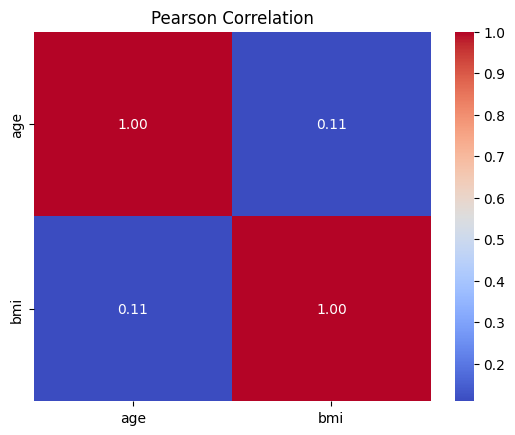

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['age', 'bmi']].corr(method='pearson')

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation')
plt.show()

In [106]:
df_cleaned.columns


Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'region', 'charges',
       'bmi_level'],
      dtype='object')

In [108]:
corr = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges']].corr(method='pearson')

corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']

corr_pairs = corr_pairs[corr_pairs['Variable 1'] != corr_pairs['Variable 2']]

corr_pairs['pair'] = corr_pairs.apply(
    lambda x: tuple(sorted([x['Variable 1'], x['Variable 2']])),
    axis=1
)

corr_pairs = corr_pairs.drop_duplicates('pair').drop(columns='pair')

corr_pairs = corr_pairs.sort_values(
    by='Correlation',
    ascending=False
)

print(corr_pairs)

   Variable 1 Variable 2  Correlation
29  is_smoker    charges     0.787234
5         age    charges     0.298308
17        bmi    charges     0.198401
2         age        bmi     0.109344
10  is_female  is_smoker     0.076596
23   children    charges     0.067389
11  is_female    charges     0.058044
8   is_female        bmi     0.046397
3         age   children     0.041536
9   is_female   children     0.017848
15        bmi   children     0.012755
22   children  is_smoker     0.007331
16        bmi  is_smoker     0.003746
1         age  is_female    -0.019814
4         age  is_smoker    -0.025587


In [110]:
from scipy.stats import f_oneway

groups = [
    group['charges'].values
    for name, group in df_cleaned.groupby('bmi_level')
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 18.94909698885937
P-value: 4.8937308659565875e-12


In [113]:
from scipy.stats import chi2_contingency
import pandas as pd

categorical_cols = ['is_female', 'is_smoker', 'region', 'bmi_level']

results = []

for i in range(len(categorical_cols)):
    for j in range(i + 1, len(categorical_cols)):

        col1 = categorical_cols[i]
        col2 = categorical_cols[j]

        table = pd.crosstab(df_cleaned[col1], df_cleaned[col2])

        chi2, p_value, dof, expected = chi2_contingency(table)

        results.append([col1, col2, chi2, p_value])

results_df = pd.DataFrame(
    results,
    columns=['Variable 1', 'Variable 2', 'Chi-Square', 'P-value']
)

results_df = results_df.sort_values('P-value')

print(results_df)

  Variable 1 Variable 2  Chi-Square       P-value
5     region  bmi_level   56.379288  6.642805e-09
0  is_female  is_smoker    7.469139  6.276555e-03
3  is_smoker     region    7.277903  6.354827e-02
2  is_female  bmi_level    3.513596  3.190030e-01
4  is_smoker  bmi_level    0.778992  8.544850e-01
1  is_female     region    0.476910  9.239342e-01


In [114]:
from scipy.stats import ttest_ind, f_oneway
import pandas as pd

categorical_cols = ['is_female', 'is_smoker', 'region', 'bmi_level']

results = []

for col in categorical_cols:

    groups = [
        group['charges'].values
        for name, group in df_cleaned.groupby(col)
    ]

    # Binary categorical variable → t-test
    if len(groups) == 2:
        statistic, p_value = ttest_ind(groups[0], groups[1])

        test = "T-test"

    # More than 2 categories → ANOVA
    else:
        statistic, p_value = f_oneway(*groups)

        test = "ANOVA"

    results.append([
        col,
        test,
        statistic,
        p_value
    ])

results_df = pd.DataFrame(
    results,
    columns=['Categorical Variable', 'Test', 'Statistical Value', 'P-value']
)

results_df = results_df.sort_values('P-value')

print(results_df)

  Categorical Variable    Test  Statistical Value        P-value
1            is_smoker  T-test         -46.644795  1.406722e-282
3            bmi_level   ANOVA          18.949097   4.893731e-12
2               region   ANOVA           2.926140   3.276288e-02
0            is_female  T-test          -2.124391   3.382079e-02


In [115]:
from scipy.stats import ttest_ind, f_oneway
import pandas as pd

categorical_cols = ['is_female', 'is_smoker', 'region', 'bmi_level']

results = []

for col in categorical_cols:

    groups = [
        group['charges'].values
        for name, group in df_cleaned.groupby(col)
    ]

    # Binary categorical variable → T-test
    if len(groups) == 2:
        statistic, p_value = ttest_ind(groups[0], groups[1])
        test = "T-test"

    # More than 2 categories → ANOVA
    else:
        statistic, p_value = f_oneway(*groups)
        test = "ANOVA"

    # Decision
    if p_value < 0.05:
        decision = "Significant"
    else:
        decision = "Not Significant"

    results.append([
        col,
        test,
        statistic,
        p_value,
        decision
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Categorical Variable',
        'Test',
        'Statistical Value',
        'P-value',
        'Decision'
    ]
)

results_df = results_df.sort_values('P-value')

print(results_df)

  Categorical Variable    Test  Statistical Value        P-value     Decision
1            is_smoker  T-test         -46.644795  1.406722e-282  Significant
3            bmi_level   ANOVA          18.949097   4.893731e-12  Significant
2               region   ANOVA           2.926140   3.276288e-02  Significant
0            is_female  T-test          -2.124391   3.382079e-02  Significant


In [116]:
df_cleaned

,age,is_female,bmi,children,is_smoker,region,charges,bmi_level
0,-1.440418,0,-0.453160,-0.909234,1,southwest,16884.92400,Overweight
1,-1.511647,1,0.509422,-0.079442,0,southeast,1725.55230,Obese
2,-0.799350,1,0.383155,1.580143,0,southeast,4449.46200,Obese
3,-0.443201,1,-1.305052,-0.909234,0,northwest,21984.47061,Normal
4,-0.514431,1,-0.292456,-0.909234,0,northwest,3866.85520,Overweight
...,...,...,...,...,...,...,...,...
1333,0.767704,1,0.050269,1.580143,0,northwest,10600.54830,Obese
1334,-1.511647,0,0.206053,-0.909234,0,northeast,2205.98080,Obese
1335,-1.511647,0,1.014490,-0.909234,0,southeast,1629.83350,Obese
1336,-1.297958,0,-0.797524,-0.909234,0,southwest,2007.94500,Overweight


In [119]:
df_cleaned['obese'] = (df_cleaned['bmi'] >= 30).astype(int)


In [120]:
df_cleaned

,age,is_female,bmi,children,is_smoker,region,charges,bmi_level,obese
0,-1.440418,0,-0.453160,-0.909234,1,southwest,16884.92400,Overweight,0
1,-1.511647,1,0.509422,-0.079442,0,southeast,1725.55230,Obese,0
2,-0.799350,1,0.383155,1.580143,0,southeast,4449.46200,Obese,0
3,-0.443201,1,-1.305052,-0.909234,0,northwest,21984.47061,Normal,0
4,-0.514431,1,-0.292456,-0.909234,0,northwest,3866.85520,Overweight,0
...,...,...,...,...,...,...,...,...,...
1333,0.767704,1,0.050269,1.580143,0,northwest,10600.54830,Obese,0
1334,-1.511647,0,0.206053,-0.909234,0,northeast,2205.98080,Obese,0
1335,-1.511647,0,1.014490,-0.909234,0,southeast,1629.83350,Obese,0
1336,-1.297958,0,-0.797524,-0.909234,0,southwest,2007.94500,Overweight,0
